In [1]:
##Make a list of all things a pizza shop owner would like to know to increase sales. Here is a sample list of questions but add more – this is your final project!
##1.Which pizza types sell most?
##2.Which ingredients are in demand?
##3.Are there more (or less) sales of a certain type of pizza in a certain month, or day, or time of the da?
##4.Which pizza sizes are sold more often, which type, which ingerdients, etc. 
##5.Is there a time of the day when there is a peak sale? If yes, does that depend on the day of the week, or month?
##6.Which size pizza sold more
##7.Most Used Ingredient


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns
%matplotlib inline

In [3]:
f_name='Data Model - Pizza Sales.xlsx'
df=pd.read_excel(f_name)
df

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_details_id   48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_id           48620 non-null  object        
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[ns]
 5   order_time         48620 non-null  object        
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  object        
 9   pizza_category     48620 non-null  object        
 10  pizza_ingredients  48620 non-null  object        
 11  pizza_name         48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 4.5+ MB


<div class="alert alert-danger">1.Which pizza types sell most?</div>

In [26]:
df1=df.groupby(['pizza_name','pizza_category'])['pizza_category'].count()
df1.sort_values(ascending=False)

pizza_name                                  pizza_category
The Classic Deluxe Pizza                    Classic           2416
The Barbecue Chicken Pizza                  Chicken           2372
The Hawaiian Pizza                          Classic           2370
The Pepperoni Pizza                         Classic           2369
The Thai Chicken Pizza                      Chicken           2315
The California Chicken Pizza                Chicken           2302
The Spicy Italian Pizza                     Supreme           1887
The Sicilian Pizza                          Supreme           1887
The Southwest Chicken Pizza                 Chicken           1885
The Four Cheese Pizza                       Veggie            1850
The Italian Supreme Pizza                   Supreme           1849
The Big Meat Pizza                          Classic           1811
The Vegetables + Vegetables Pizza           Veggie            1510
The Mexicana Pizza                          Veggie            1456
The

<font color = blue>**The highest sold pizza is The Classic Deluxe Pizza  which is 2416 times**</font>  </br>

<div class="alert alert-danger">2.Which ingredients are in demand?</div>

In [27]:
pd.set_option('display.max_colwidth',None)
df1=df['pizza_ingredients'].value_counts().reset_index(name='numer of times')
df1
##ref:https://www.youtube.com/watch?v=5Agmh_A1F-Q

,index,numer of times
0,"Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon",2416
1,"Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce",2372
2,"Sliced Ham, Pineapple, Mozzarella Cheese",2370
3,"Mozzarella Cheese, Pepperoni",2369
4,"Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce",2315
5,"Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese",2302
6,"Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic",1887
7,"Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic",1887
8,"Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce",1885
9,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mozzarella Cheese, Parmigiano Reggiano Cheese, Garlic",1850


In [28]:
print("The top 5 ingredients in demand are :")
df1.head(5)

The top 5 ingredients in demand are :


,index,numer of times
0,"Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon",2416
1,"Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce",2372
2,"Sliced Ham, Pineapple, Mozzarella Cheese",2370
3,"Mozzarella Cheese, Pepperoni",2369
4,"Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce",2315


<div class="alert alert-danger">3.Are there more (or less) sales of a certain type of pizza in a certain month, or day, or time of the da?</div>

In [29]:
df['order_date']=pd.to_datetime(df['order_date'])
df1=df.groupby(['pizza_name','order_date']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,pizza_name,order_date,count
4395,The Hawaiian Pizza,2015-11-26,21
2646,The Classic Deluxe Pizza,2015-11-27,20
6978,The Pepperoni Pizza,2015-05-15,18
1360,The California Chicken Pizza,2015-02-20,16
338,The Barbecue Chicken Pizza,2015-12-11,16
...,...,...,...
6237,The Napolitana Pizza,2015-04-12,1
6236,The Napolitana Pizza,2015-04-11,1
3783,The Green Garden Pizza,2015-02-22,1
6235,The Napolitana Pizza,2015-04-10,1


<font color = blue>**The Hawaiian Pizza is highest sold pizza in a day which is in 2015-11-26**</font>  </br>

<div class="alert alert-success">#The day which has maximum sale</div>

In [30]:
df['order_date']=pd.to_datetime(df['order_date']) #converting to date format and removing time stamp
df['Day']=df['order_date'].dt.day_name()#converting date into day of the week
df1=df.groupby(['pizza_name','Day']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,pizza_name,Day,count
140,The Pepperoni Pizza,Friday,462
49,The Classic Deluxe Pizza,Friday,404
0,The Barbecue Chicken Pizza,Friday,396
28,The California Chicken Pizza,Friday,386
210,The Thai Chicken Pizza,Friday,378
...,...,...,...
14,The Brie Carre Pizza,Friday,70
20,The Brie Carre Pizza,Wednesday,67
19,The Brie Carre Pizza,Tuesday,67
15,The Brie Carre Pizza,Monday,66


<font color = blue> **Friday has the highest number of pizza sales for The Pepperoni Pizza which is 462.** </font>  </br>

In [31]:
df['order_date']=pd.to_datetime(df['order_date']) #converting to date format and removing time stamp
df['Week']=df['order_date'].dt.isocalendar().week#converting date into day of the week
df1=df.groupby(['pizza_name','Week']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,pizza_name,Week,count
418,The Classic Deluxe Pizza,48,66
397,The Classic Deluxe Pizza,27,65
1079,The Pepperoni Pizza,20,63
9,The Barbecue Chicken Pizza,10,62
1266,The Sicilian Pizza,48,60
...,...,...,...
144,The Brie Carre Pizza,39,4
108,The Brie Carre Pizza,3,4
159,The Calabrese Pizza,1,4
127,The Brie Carre Pizza,22,4


<font color = blue>**The highest sold pizza in a week is The Classic Deluxe Pizza which is in week 48**</font>  </br>

In [32]:
df['order_date']=pd.to_datetime(df['order_date']) #converting to date format and removing time stamp
df['Week']=df['order_date'].dt.isocalendar().week#converting date into day of the week
df1=df.groupby(['Week']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,Week,count
47,48,1159
26,27,1048
19,20,1027
13,14,1001
48,49,996
36,37,994
39,40,986
22,23,983
32,33,981
5,6,972


<font color = blue>**The maximum sale is in the week 48 which is 1159.**</font>  </br>

<div class="alert alert-success">#sale for the month</div>

In [33]:
df['order_date']=pd.to_datetime(df['order_date']) #converting to date format and removing time stamp
df['Month']=df['order_date'].dt.month#converting date into day of the week
df1=df.groupby(['Month']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,Month,count
6,7,4301
4,5,4239
2,3,4186
10,11,4185
0,1,4156
7,8,4094
3,4,4067
5,6,4025
1,2,3892
11,12,3859


<font color = blue>**Month 7 i.e. July has the higesth number of pizza sales**</font>  </br>

<div class="alert alert-danger">4.Which pizza sizes are sold more often, which type, which ingerdients, etc.?</div>

<div class="alert alert-success">#size of pizza</div>

In [34]:
df1=df.groupby(['pizza_size']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,pizza_size,count
0,L,18526
1,M,15385
2,S,14137
3,XL,544
4,XXL,28


<font color = blue>**The most sold pizza is large which is 18526 times.**</font>  </br>

<div class="alert alert-success">#Type of pizza</div>

In [32]:
df1=df.groupby(['pizza_category'])['pizza_category'].count()
df1.sort_values(ascending=False)

pizza_category
Classic    14579
Supreme    11777
Veggie     11449
Chicken    10815
Name: pizza_category, dtype: int64

<font color = blue>**Classic pizza is the most sold pizza.**</font>  </br>

<div class="alert alert-success">#which ingridents</div>

In [35]:
##df1=df['pizza_ingredients'].value_counts().reset_index(name='numer of times')
#df1.head()

name_pizzas = df['pizza_ingredients'].value_counts()
name_pizzas

Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                                 2416
Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce                  2372
Sliced Ham, Pineapple, Mozzarella Cheese                                                             2370
Mozzarella Cheese, Pepperoni                                                                         2369
Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                                   2315
Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese                  2302
Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic                     1887
Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic                              1887
Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce         1885
Ricotta Cheese, Gorgonzola Piccante Cheese, Mo

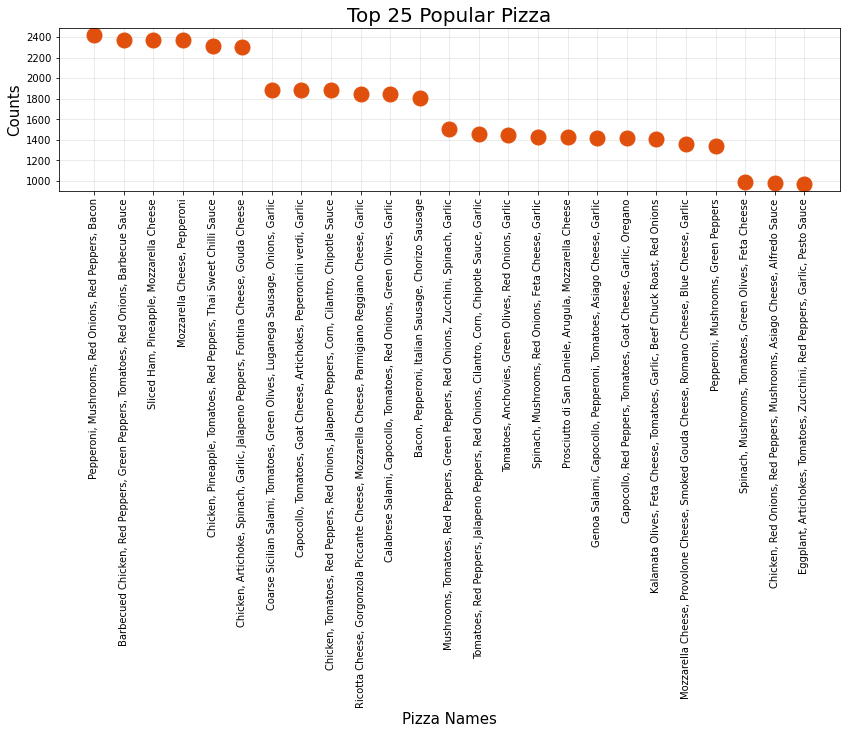

In [37]:
plt.figure(figsize=(14,3))
plt.plot(name_pizzas.head(25), linestyle='none', markersize=15, marker='o',color='#e04f0b')
plt.title('Top 25 Popular Pizza', fontsize=20)
plt.xticks(rotation=90)
plt.xlabel('Pizza Names', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.grid(alpha=.3)
plt.margins(.05)
plt.show()

<font color = blue>**The maximum used ingredients int the pizza is "Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon"**</font>  </br>

<div class="alert alert-danger">5.Is there a time of the day when there is a peak sale? If yes, does that depend on the day of the week, or month?</div>

In [73]:
df1=df.groupby(['order_time']).size().reset_index(name='count')
df1.sort_values(by='count',ascending=False)

,order_time,count
1927,12:32:00,26
954,11:59:10,24
2577,12:53:29,23
1733,12:26:04,23
2555,12:52:36,23
...,...,...
2485,12:50:15,1
2488,12:50:20,1
5344,14:36:45,1
2492,12:50:31,1


<font color = blue> **The time of the day which has maximum order is 12:32:00 which is 26.** </font>  </br>

In [65]:
df

,order_details_id,order_id,pizza_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,Day,Week
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Thursday,1
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon",The Classic Deluxe Pizza,Thursday,1
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Gouda Cheese, Romano Cheese, Blue Cheese, Garlic",The Five Cheese Pizza,Thursday,1
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic",The Italian Supreme Pizza,Thursday,1
4,5,2,mexicana_m,1,2015-01-01,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red Onions, Cilantro, Corn, Chipotle Sauce, Garlic",The Mexicana Pizza,Thursday,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, Asiago Cheese, Alfredo Sauce",The Chicken Alfredo Pizza,Thursday,53
48616,48617,21348,four_cheese_l,1,2015-12-31,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mozzarella Cheese, Parmigiano Reggiano Cheese, Garlic",The Four Cheese Pizza,Thursday,53
48617,48618,21348,napolitana_s,1,2015-12-31,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions, Garlic",The Napolitana Pizza,Thursday,53
48618,48619,21349,mexicana_l,1,2015-12-31,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red Onions, Cilantro, Corn, Chipotle Sauce, Garlic",The Mexicana Pizza,Thursday,53


<div class="alert alert-danger">6.Which size pizza sold more</div>

In [4]:
#Which pizza size sold more
Size_count = df.pizza_size.value_counts()
Size_count

L      18526
M      15385
S      14137
XL       544
XXL       28
Name: pizza_size, dtype: int64

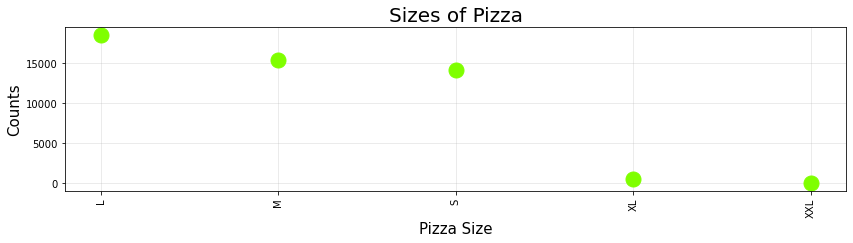

In [43]:
plt.figure(figsize=(14,3))
plt.plot(Size_count.head(25), linestyle='none', markersize=15, marker='o',color='#7FFF00')
plt.title('Sizes of Pizza', fontsize=20)
plt.xticks(rotation=90)
plt.xlabel('Pizza Size', fontsize=15)
plt.ylabel('Counts', fontsize=15)
plt.grid(alpha=.3)
plt.margins(.05)
plt.show()

<div class="alert alert-danger">7.Most Used Ingredients</div>

In [7]:
x = df['pizza_ingredients'].to_list()

In [9]:
x

['Sliced Ham, Pineapple, Mozzarella Cheese',
 'Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon',
 'Mozzarella Cheese, Provolone Cheese, Smoked Gouda Cheese, Romano Cheese, Blue Cheese, Garlic',
 'Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic',
 'Tomatoes, Red Peppers, Jalapeno Peppers, Red Onions, Cilantro, Corn, Chipotle Sauce, Garlic',
 'Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce',
 'Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic',
 'Prosciutto di San Daniele, Arugula, Mozzarella Cheese',
 'Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic',
 'Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic',
 'Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce',
 'Kalamata Olives, Feta Cheese, Tomatoes, Garlic, Beef Chuck Roast, Red Onions',
 'Spinach, Red Onions, Pepperoni, Tomatoes, Artichokes, Kalamata Olives, Garlic, Asiago Cheese',
 'Spin

In [10]:
# using split function Seperated each ingredients
ing = []
for i in x:
    tmp = list(i.split(','))
    ing.extend(tmp)

In [11]:
ing

['Sliced Ham',
 ' Pineapple',
 ' Mozzarella Cheese',
 'Pepperoni',
 ' Mushrooms',
 ' Red Onions',
 ' Red Peppers',
 ' Bacon',
 'Mozzarella Cheese',
 ' Provolone Cheese',
 ' Smoked Gouda Cheese',
 ' Romano Cheese',
 ' Blue Cheese',
 ' Garlic',
 'Calabrese Salami',
 ' Capocollo',
 ' Tomatoes',
 ' Red Onions',
 ' Green Olives',
 ' Garlic',
 'Tomatoes',
 ' Red Peppers',
 ' Jalapeno Peppers',
 ' Red Onions',
 ' Cilantro',
 ' Corn',
 ' Chipotle Sauce',
 ' Garlic',
 'Chicken',
 ' Pineapple',
 ' Tomatoes',
 ' Red Peppers',
 ' Thai Sweet Chilli Sauce',
 'Calabrese Salami',
 ' Capocollo',
 ' Tomatoes',
 ' Red Onions',
 ' Green Olives',
 ' Garlic',
 'Prosciutto di San Daniele',
 ' Arugula',
 ' Mozzarella Cheese',
 'Calabrese Salami',
 ' Capocollo',
 ' Tomatoes',
 ' Red Onions',
 ' Green Olives',
 ' Garlic',
 'Calabrese Salami',
 ' Capocollo',
 ' Tomatoes',
 ' Red Onions',
 ' Green Olives',
 ' Garlic',
 'Barbecued Chicken',
 ' Red Peppers',
 ' Green Peppers',
 ' Tomatoes',
 ' Red Onions',
 ' Barbe

In [12]:
# most of the ingredients have whitespace
# remove whitespace from ing
for s in range(len(ing)):
    ing[s] = ing[s].strip()

In [14]:
# repeated ingredients 
import collections

c = collections.Counter(ing)
                  
d = [(a,b) for b,a in sorted([(j,i) for i,j in c.items()], reverse = True)]

In [15]:
d[0]

('Garlic', 27422)

In [16]:
 print("Most used ingredient is:", d[0][0], "and count is", d[0][1])

Most used ingredient is: Garlic and count is 27422
